In [1]:
!pip install torch-fidelity --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

import torch
import torch.nn as nn

import torchvision
import torchvision.transforms as transforms

In [3]:
SEED = 42
IMAGE_SIZE = 64
BATCH_SIZE = 128
NUM_EPOCHS = 200
LEARNING_RATE = 1e-4

In [4]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

In [5]:
device = "cpu"
if torch.cuda.is_available():
    print(f"Cuda Version:{torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    device = "cuda"
print(f"Using device: {device}")

Cuda Version:12.8
GPU Memory: 15.6 GB
Using device: cuda


## Dataset Exploration

In [6]:
root_data_dir = Path('/kaggle/input/datasets/aditibindal/deeplense-generative-dataset/Samples')
sample1 = np.load(root_data_dir/'sample1.npy')
sample1.shape

(1, 150, 150)

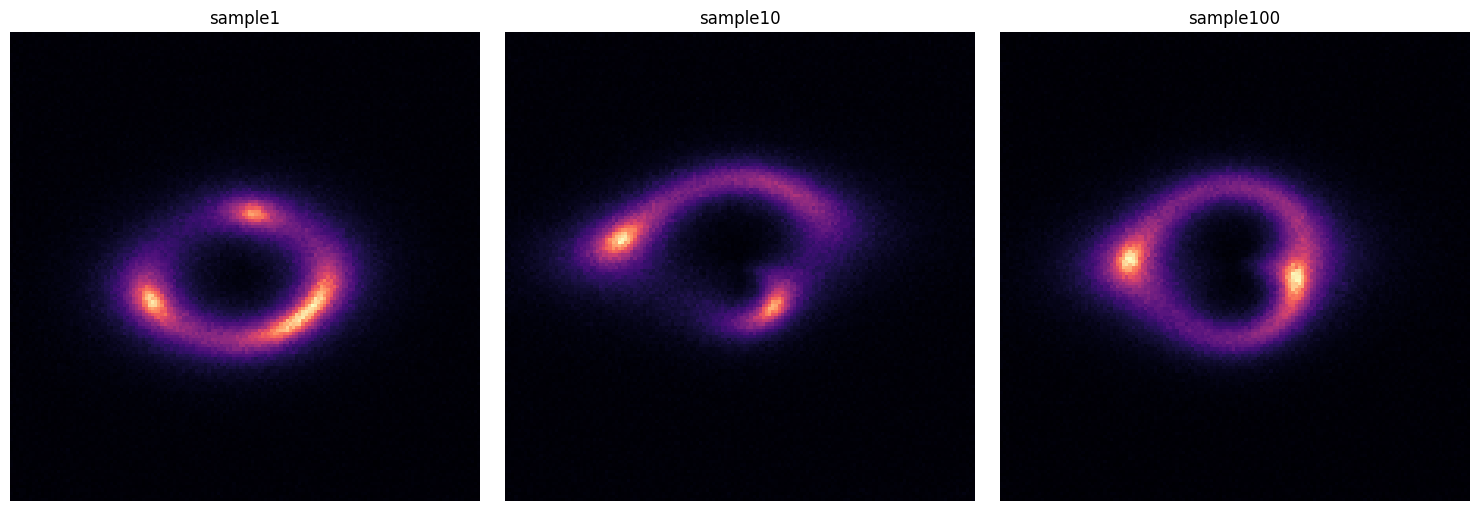

In [7]:
sample1 = np.load(root_data_dir/'sample1.npy')
sample10 = np.load(root_data_dir/'sample10.npy')
sample100 = np.load(root_data_dir/'sample100.npy')

def plot_train_samples(samples_dict):
    plt.figure(figsize=(15, 5))
    
    for i, (label, img) in enumerate(samples_dict.items()):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img[0], cmap="magma")
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

samples = {
    "sample1": sample1,
    "sample10": sample10,
    "sample100": sample100,
}

plot_train_samples(samples)

In [8]:
print(f"Array Shape: {sample1.shape}")
print(f"Min value: {sample1.min()}")
print(f"Max value: {sample1.max()}")
print(f"Data type: {sample1.dtype}")

Array Shape: (1, 150, 150)
Min value: 0.0
Max value: 1.0
Data type: float64


## Dataset Preparation

In [9]:
from torch.utils.data import Dataset

class GenerativeLenseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.filepaths = []
        
        if os.path.exists(self.root_dir):
            for file in os.listdir(self.root_dir):
                if file.endswith('.npy'):
                    self.filepaths.append(os.path.join(self.root_dir, file))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, i):
        img_path = self.filepaths[i]
        image = np.load(img_path) 
        
        if image.ndim == 2:
            image = np.expand_dims(image, axis=0)
            
        image = torch.tensor(image, dtype=torch.float32)
        if self.transform:
            image = self.transform(image)

        return image

In [10]:
def create_transform_pipelines(img_size):
    
    diffusion_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size), antialias=True),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    return diffusion_transforms

train_transform = create_transform_pipelines(img_size=IMAGE_SIZE)
val_transform = create_transform_pipelines(img_size=IMAGE_SIZE)

In [11]:
from torch.utils.data import DataLoader, random_split

def create_datasets_and_dataloaders(data_dir, transform, batch_size, num_workers):

    full_dataset = GenerativeLenseDataset(root_dir=data_dir, transform=transform)
    
    num_images = len(full_dataset)
    train_size = int(0.9 * num_images)
    val_size = num_images - train_size
    
    train_subset, val_subset = random_split(
        full_dataset, 
        [train_size, val_size], 
        generator=torch.Generator().manual_seed(42)
    )
    
    pin_mem = torch.cuda.is_available()
    
    train_dataloader = DataLoader(dataset=train_subset,
                                 batch_size=batch_size,
                                 shuffle=True,
                                 num_workers=num_workers,
                                 persistent_workers=True,
                                 pin_memory=pin_mem,
                                 drop_last=True)

    val_dataloader = DataLoader(dataset=val_subset,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                persistent_workers=True,
                                pin_memory=pin_mem,
                                drop_last=False)
    
    return train_subset, val_subset, train_dataloader, val_dataloader

train_subset, val_subset, train_dataloader, val_dataloader = create_datasets_and_dataloaders(
    data_dir=root_data_dir,
    transform=train_transform,
    batch_size=BATCH_SIZE,
    num_workers=2
)

print("=== GENERATIVE DATASET & DATALOADER SUMMARY ===")
print(f"Total images loaded: {len(train_subset) + len(val_subset)}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print("-" * 45)
print(f"Batch size: {train_dataloader.batch_size}")
print(f"Training batches per epoch: {len(train_dataloader)}")
print(f"Validation batches per epoch: {len(val_dataloader)}")
print(f"Tensor shape per batch: {next(iter(train_dataloader)).shape}")

=== GENERATIVE DATASET & DATALOADER SUMMARY ===
Total images loaded: 10000
Training samples: 9000
Validation samples: 1000
---------------------------------------------
Batch size: 128
Training batches per epoch: 70
Validation batches per epoch: 8
Tensor shape per batch: torch.Size([128, 1, 64, 64])


In [12]:
check_batch = next(iter(train_dataloader))
print(f"Data Min: {check_batch.min().item()}")
print(f"Data Max: {check_batch.max().item()}")
print(f"Data Mean: {check_batch.mean().item()}")

Data Min: -0.9871506094932556
Data Max: 0.884289026260376
Data Mean: -0.8759719729423523


## Build Model

In [13]:
def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.0
    omega = 1.0 / 10000**omega

    pos = pos.reshape(-1)
    out = np.einsum("m,d->md", pos, omega)

    emb_sin = np.sin(out)
    emb_cos = np.cos(out)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    return emb

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])

    emb = np.concatenate([emb_h, emb_w], axis=1)
    return emb

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    return pos_embed

In [14]:
import math

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=1, embed_dim=512):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.freq_dim = frequency_embedding_size
    def forward(self, t):
        half = self.freq_dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(start=0, end=half, dtype=torch.float32).to(t.device) / half)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        return self.mlp(embedding)

class DiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.GELU(),
            nn.Linear(hidden_size * 4, hidden_size)
        )
        self.adaLN_modulation = nn.Sequential(nn.SiLU(), nn.Linear(hidden_size, 6 * hidden_size))
    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=1)
        attn_out, _ = self.attn(modulate(self.norm1(x), shift_msa, scale_msa), 
                                modulate(self.norm1(x), shift_msa, scale_msa), 
                                modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_msa.unsqueeze(1) * attn_out
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x

class NanoDiT(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=1, hidden_size=256, depth=6, num_heads=8):
        super().__init__()
        self.out_channels = in_chans
        self.patch_size = patch_size
        self.x_embedder = PatchEmbed(img_size, patch_size, in_chans, hidden_size)
        self.t_embedder = TimestepEmbedder(hidden_size)
   
        num_patches = self.x_embedder.num_patches
        grid_size = int(num_patches ** 0.5)
        
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, hidden_size), requires_grad=False)
        
        pos_embed = get_2d_sincos_pos_embed(hidden_size, grid_size)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))
        
        self.blocks = nn.ModuleList([DiTBlock(hidden_size, num_heads) for _ in range(depth)])
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.linear_final = nn.Linear(hidden_size, patch_size * patch_size * in_chans)
        self.adaLN_final = nn.Sequential(nn.SiLU(), nn.Linear(hidden_size, 2 * hidden_size))

    def forward(self, x, t):
        x = self.x_embedder(x) + self.pos_embed
        c = self.t_embedder(t)
        
        for block in self.blocks:
            x = block(x, c)
            
        shift, scale = self.adaLN_final(c).chunk(2, dim=1)
        x = self.linear_final(modulate(self.norm_final(x), shift, scale))
        
        B, T, C = x.shape
        h = w = int(T ** 0.5)
        p = self.patch_size
        x = x.reshape(B, h, w, p, p, self.out_channels).permute(0, 5, 1, 3, 2, 4).reshape(B, self.out_channels, h*p, w*p)
        return x

model = NanoDiT(
    img_size=64, 
    patch_size=4,
    hidden_size=256, 
    depth=6, 
    num_heads=8
)


num_patches = model.x_embedder.num_patches
grid_size = int(num_patches ** 0.5)
pos_embed = get_2d_sincos_pos_embed(256, grid_size)
model.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    
model = model.to(device)

## Train Model

In [15]:
import time
import copy

def train_diffusion(model, train_dataloader, val_dataloader, optimizer, device, epochs=NUM_EPOCHS):
    print("Starting Diffusion Training...")
    criterion = nn.MSELoss()
    scaler = torch.amp.GradScaler('cuda')
    
    start_time = time.time()
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    results = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # TRAINING
        model.train()
        train_loss = 0.0
        train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        
        for images in train_bar:
            x1 = images.to(device)
            B = x1.shape[0]
            
            x0 = torch.randn_like(x1)
            t = torch.rand(B, device=device)
            t_expand = t.view(B, 1, 1, 1)
            
            xt = (1 - t_expand) * x0 + t_expand * x1
            target_velocity = x1 - x0
            
            optimizer.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                predicted_velocity = model(xt, t) 
                loss = criterion(predicted_velocity, target_velocity)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()

        # VALIDATION
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images in val_dataloader:
                x1 = images.to(device)
                B = x1.shape[0]
                
                x0 = torch.randn_like(x1)
                t = torch.rand(B, device=device)
                t_expand = t.view(B, 1, 1, 1)
                
                xt = (1 - t_expand) * x0 + t_expand * x1
                target_velocity = x1 - x0
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    predicted_velocity = model(xt, t)
                    loss = criterion(predicted_velocity, target_velocity)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        results['train_loss'].append(avg_train_loss)
        results['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch+1:2d} | TRAIN: {avg_train_loss:.5f} | VAL: {avg_val_loss:.5f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_diffusion_model.pth')
            print(f"New best model found. Saved weights.")

    model.load_state_dict(best_model_wts)
    return model, results

In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
model, results = train_diffusion(model, train_dataloader, val_dataloader, optimizer, device, epochs=NUM_EPOCHS)

Starting Diffusion Training...


Epoch 1/200 [Train]:   0%|          | 0/70 [00:01<?, ?it/s]

Epoch  1 | TRAIN: 0.84773 | VAL: 0.21158
New best model found. Saved weights.


Epoch 2/200 [Train]:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch  2 | TRAIN: 0.16241 | VAL: 0.12043
New best model found. Saved weights.


...

Epoch 198 | TRAIN: 0.02059 | VAL: 0.02106


Epoch 199/200 [Train]:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 199 | TRAIN: 0.01991 | VAL: 0.02107


Epoch 200/200 [Train]:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 200 | TRAIN: 0.02063 | VAL: 0.02226


In [17]:
# path = '/kaggle/working/best_nanodit_model.pth'
# state_dict = torch.load(path, map_location=device)

# from collections import OrderedDict
# new_state_dict = OrderedDict()
# for k, v in state_dict.items():
#     name = k[7:] if k.startswith('module.') else k
#     new_state_dict[name] = v

# model.load_state_dict(new_state_dict)

# print(f"Model successfully loaded from {path}")
# print(f"Ready for inference on {device}.")

## Inference and Evaluation

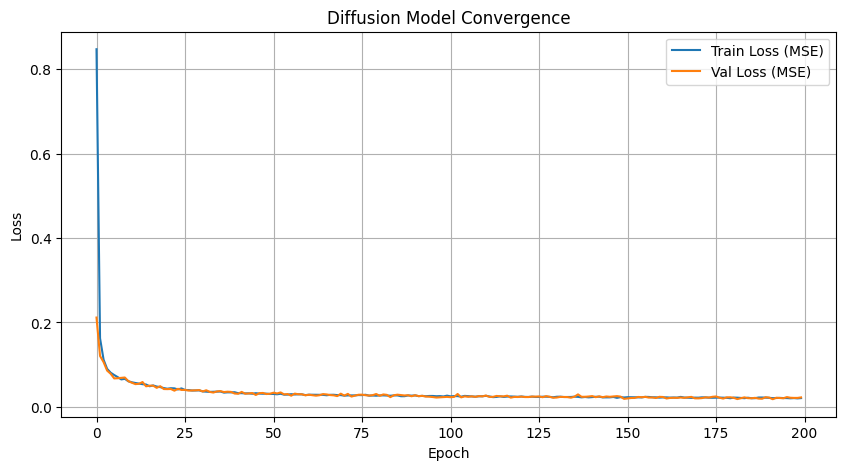

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(results['train_loss'], label='Train Loss (MSE)')
plt.plot(results['val_loss'], label='Val Loss (MSE)')
plt.title('Diffusion Model Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
@torch.no_grad()
def sample_baseline(model, num_samples=8, ode_steps=100, device='cuda'):
    model.eval()
    z = torch.randn(num_samples, 1, 64, 64, device=device) 
    dt = 1.0 / ode_steps
    for i in range(ode_steps):
        t = torch.tensor([i / ode_steps] * num_samples, device=device)
        v = model(z, t)
        z = z + dt * v 
    return torch.clamp(z, -1.0, 1.0)

@torch.no_grad()
def sample_pcfm(model, expected_mass, num_samples=8, ode_steps=100, device='cuda'):
    model.eval()
    z = torch.randn(num_samples, 1, 64, 64, device=device)
    dt = 1.0 / ode_steps
    for i in range(ode_steps):
        t_val = i / ode_steps
        t = torch.tensor([t_val] * num_samples, device=device)
        v = model(z, t)
        
        t_safe = max(t_val, 1e-3)
        hat_x_data = (z - (1 - t_safe) * torch.randn_like(z)) / t_safe
        current_mass = hat_x_data.mean(dim=(1,2,3), keepdim=True)
        residual = current_mass - expected_mass
        
        z_proj = z - 0.05 * residual 
        v_proj = model(z_proj, t)
        z = z_proj + dt * v_proj
    return torch.clamp(z, -1.0, 1.0)

Extracting physical prior from training data...
Generating Baseline and PCFM samples...


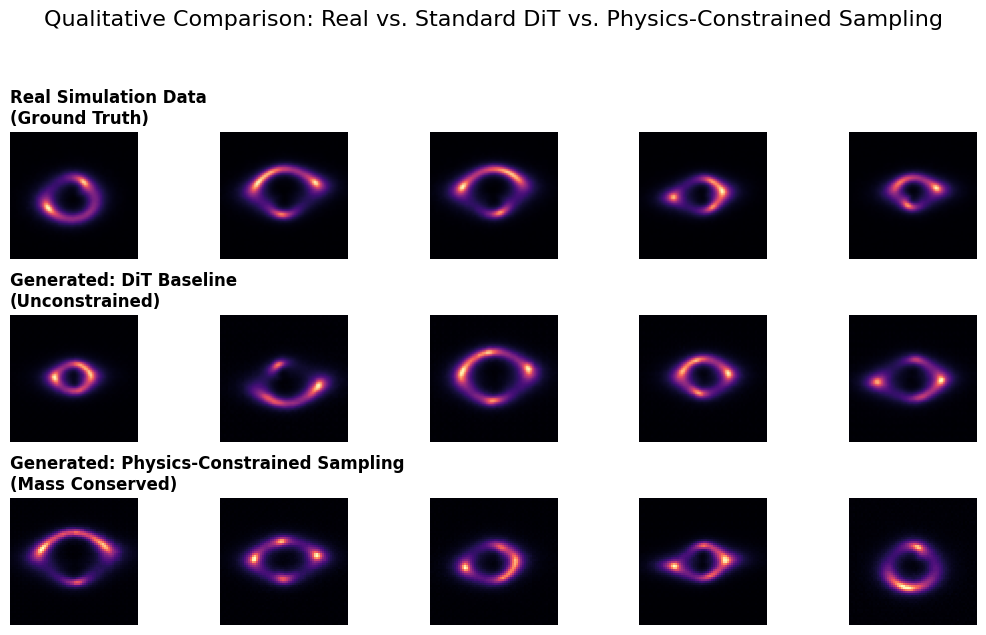

In [20]:
print("Extracting physical prior from training data...")
real_batch = next(iter(train_dataloader))
expected_mass_prior = real_batch.mean().item()

num_vis_samples = 5

real_imgs = real_batch[:num_vis_samples]

print("Generating Baseline and PCFM samples...")
baseline_imgs = sample_baseline(model, num_samples=num_vis_samples, device=device)
pcfm_imgs = sample_pcfm(model, expected_mass_prior, num_samples=num_vis_samples, device=device)

def show_img(img_tensor):
    img = (img_tensor.cpu().squeeze() + 1.0) / 2.0
    return img

fig, axes = plt.subplots(3, num_vis_samples, figsize=(2 * num_vis_samples, 6))

for i in range(num_vis_samples):
    # Top Row: Real Simulations
    axes[0, i].imshow(show_img(real_imgs[i]), cmap='magma')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Real Simulation Data\n(Ground Truth)", fontweight='bold', loc='left')
    
    # Middle Row: Standard Baseline
    axes[1, i].imshow(show_img(baseline_imgs[i]), cmap='magma')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Generated: DiT Baseline\n(Unconstrained)", fontweight='bold', loc='left')
    
    # Bottom Row: Physics-Constrained Sampling
    axes[2, i].imshow(show_img(pcfm_imgs[i]), cmap='magma')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Generated: Physics-Constrained Sampling\n(Mass Conserved)", fontweight='bold', loc='left')

plt.suptitle("Qualitative Comparison: Real vs. Standard DiT vs. Physics-Constrained Sampling", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [21]:
from torchmetrics.image import FrechetInceptionDistance
def evaluate_comparison_fid_and_physics(model, dataloader, expected_mass, num_total_samples=400, batch_size=50, device='cuda'):
    fid_baseline = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    fid_pcfm = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    
    all_base_errors = []
    all_pcfm_errors = []

    print("Extracting Features...")
    processed_real = 0
    for batch in dataloader:
        if processed_real >= num_total_samples: break
        real_batch = batch[0] if isinstance(batch, (list, tuple)) else batch
        real_batch = real_batch.to(device)

        real_uint8 = ((real_batch + 1.0) / 2.0 * 255.0).clamp(0, 255).to(torch.uint8).repeat(1, 3, 1, 1)
        fid_baseline.update(real_uint8, real=True)
        fid_pcfm.update(real_uint8, real=True)
        processed_real += real_batch.size(0)

    print(f"\nEvaluating Baseline...")
    for _ in tqdm(range(0, num_total_samples, batch_size), desc="Baseline"):
        curr_b = min(batch_size, num_total_samples - _)
        samples = sample_baseline(model, num_samples=curr_b, device=device)
        
        all_base_errors.append(torch.abs(samples.mean(dim=(1,2,3)) - expected_mass).cpu())
        
        samples_uint8 = ((samples + 1.0) / 2.0 * 255.0).clamp(0, 255).to(torch.uint8).repeat(1, 3, 1, 1)
        fid_baseline.update(samples_uint8, real=False)

    print(f"\nEvaluating PCFM...")
    for _ in tqdm(range(0, num_total_samples, batch_size), desc="PCFM"):
        curr_b = min(batch_size, num_total_samples - _)
        samples = sample_pcfm(model, expected_mass, num_samples=curr_b, device=device)
        
        all_pcfm_errors.append(torch.abs(samples.mean(dim=(1,2,3)) - expected_mass).cpu())
        
        samples_uint8 = ((samples + 1.0) / 2.0 * 255.0).clamp(0, 255).to(torch.uint8).repeat(1, 3, 1, 1)
        fid_pcfm.update(samples_uint8, real=False)

    score_base = fid_baseline.compute().item()
    score_pcfm = fid_pcfm.compute().item()
    base_err, pcfm_err = torch.cat(all_base_errors), torch.cat(all_pcfm_errors)

    print("=" * 60)
    print(f"Standard DiT Baseline FID : {score_base:.4f} | Mass Err: {base_err.mean():.6f}")
    print(f"Physics-Constrained Sampling FID        : {score_pcfm:.4f} | Mass Err: {pcfm_err.mean():.6f}")
    print("=" * 60)
    
    return score_base, score_pcfm

In [22]:
baseline_fid, pcfm_fid = evaluate_comparison_fid_and_physics(
    model, 
    val_dataloader, 
    expected_mass_prior, 
    num_total_samples=400, 
    batch_size=50, 
    device=device
)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 268MB/s]


Extracting Features...

Evaluating Baseline...


Baseline:   0%|          | 0/8 [00:00<?, ?it/s]


Evaluating PCFM...


PCFM:   0%|          | 0/8 [00:00<?, ?it/s]

Standard DiT Baseline FID : 25.6673 | Mass Err: 0.013174
Physics-Constrained Sampling FID        : 42.0216 | Mass Err: 0.004389
